# Flickr25k — 공통 class를 가진 이미지 시각화

각 class(tag)에 대해 그 class를 공통으로 가진 이미지를 몇 장만 샘플링해서 그리드로 보여준다.
라벨은 `dataset/Flickr25k/setting1/test.txt`의 24-차원 멀티-핫 벡터를 사용한다.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATASET_ROOT = "/home/yschoi/GroundedDNA/dataset/Flickr25k"
SPLIT_FILE   = os.path.join(DATASET_ROOT, "setting1", "test.txt")

# MIRFlickr-25k 표준 24개 annotation tag (알파벳 순) — 코드베이스에 이름이 없어 index->name 매핑으로 사용.
# 이름이 안 맞더라도 라벨 index 기준 그룹핑은 정확하다.
TAG_NAMES = [
    "animals", "baby", "bird", "car", "clouds", "dog", "female", "flower",
    "food", "indoor", "lake", "male", "night", "people", "plant_life",
    "portrait", "river", "sea", "sky", "structures", "sunset", "transport",
    "tree", "water",
]

# split 파일 파싱: 각 줄 = '<상대경로> l0 l1 ... l23'
img_paths, labels = [], []
with open(SPLIT_FILE) as f:
    for line in f:
        toks = line.split()
        if not toks:
            continue
        img_paths.append(os.path.join(DATASET_ROOT, toks[0]))
        labels.append([int(x) for x in toks[1:]])

img_paths = np.array(img_paths)
labels = np.array(labels, dtype=np.int64)
n_classes = labels.shape[1]
assert n_classes == len(TAG_NAMES), (n_classes, len(TAG_NAMES))
print(f"이미지 {len(img_paths)}장, class {n_classes}개")

# class 별 빈도
freq = labels.sum(0)
for i in np.argsort(-freq):
    print(f"  [{i:2d}] {TAG_NAMES[i]:<12s} {freq[i]:4d}장")

이미지 2000장, class 24개
  [ 0] animals       799장
  [ 8] food          799장
  [ 1] baby          742장
  [22] tree          652장
  [ 5] dog           649장
  [17] sea           474장
  [ 4] clouds        472장
  [10] lake          405장
  [ 3] car           331장
  [ 9] indoor        304장
  [13] people        273장
  [14] plant_life    267장
  [12] night         223장
  [ 6] female        209장
  [16] river         171장
  [11] male          162장
  [ 2] bird          102장
  [19] structures     96장
  [18] sky            78장
  [21] transport      72장
  [20] sunset         66장
  [23] water          61장
  [15] portrait       57장
  [ 7] flower         23장


In [2]:
def tags_of(idx):
    """이미지 idx의 활성 tag 이름 목록."""
    return [TAG_NAMES[j] for j in np.where(labels[idx] == 1)[0]]

def show_class(class_id, n_samples=5, seed=0):
    """class_id를 공통으로 가진 이미지를 n_samples장 샘플링해서 한 행으로 시각화."""
    member = np.where(labels[:, class_id] == 1)[0]
    rng = np.random.default_rng(seed)
    pick = rng.choice(member, size=min(n_samples, len(member)), replace=False)

    fig, axes = plt.subplots(1, len(pick), figsize=(3 * len(pick), 3.4))
    if len(pick) == 1:
        axes = [axes]
    for ax, idx in zip(axes, pick):
        ax.imshow(Image.open(img_paths[idx]).convert("RGB"))
        ax.set_title(", ".join(tags_of(idx)), fontsize=7)
        ax.axis("off")
    fig.suptitle(
        f"\uacf5\ud1b5 class = [{class_id}] {TAG_NAMES[class_id]}  ({len(member)}\uc7a5 \uc911 {len(pick)}\uc7a5)",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2712730/4191218375.py:22: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2712730/4191218375.py:22: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2712730/4191218375.py:22: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2712730/4191218375.py:22: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/yschoi/.conda/envs/dna_hashing/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yschoi/.conda/envs/dna_hashing/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans

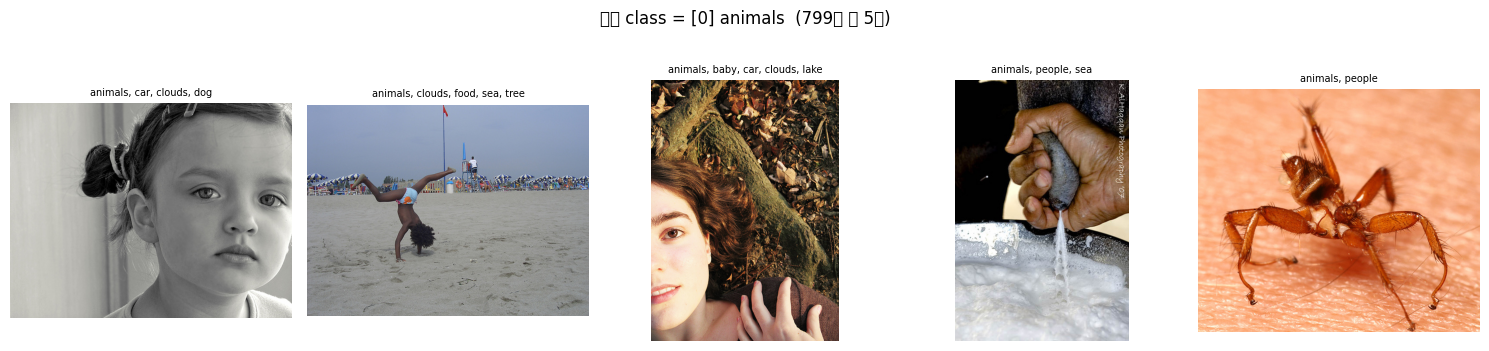

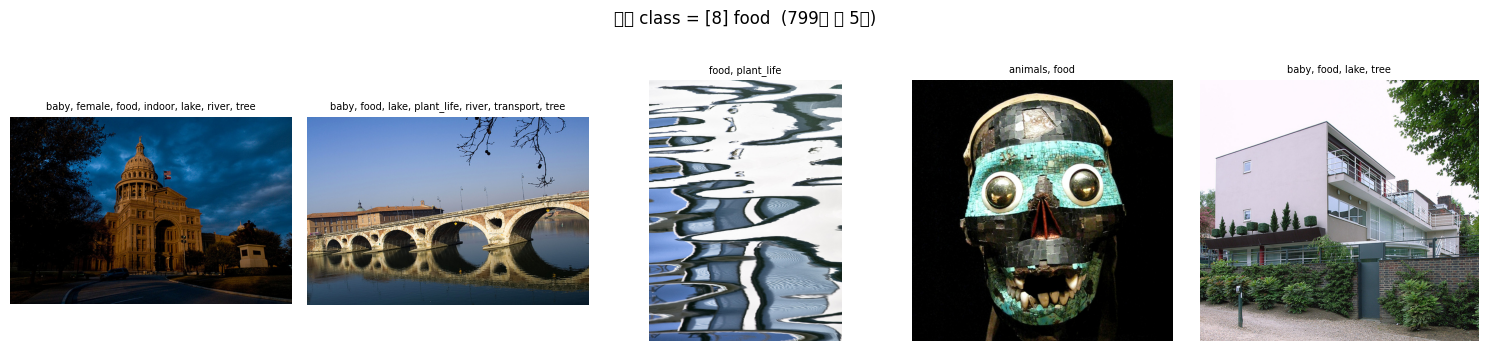

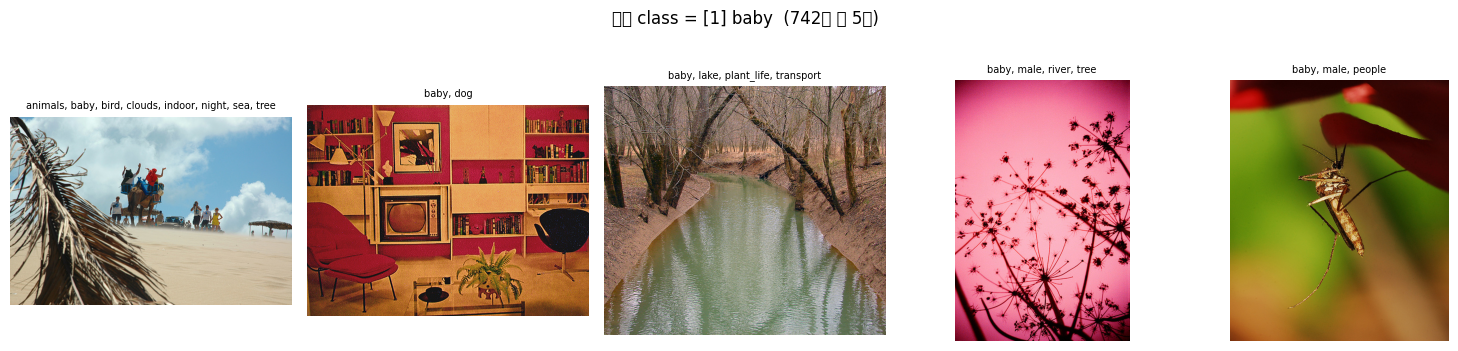

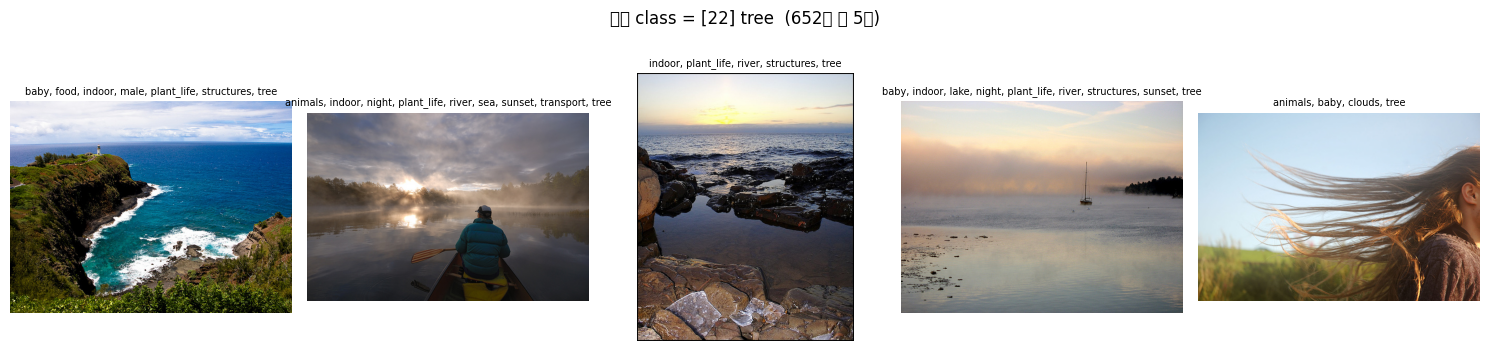

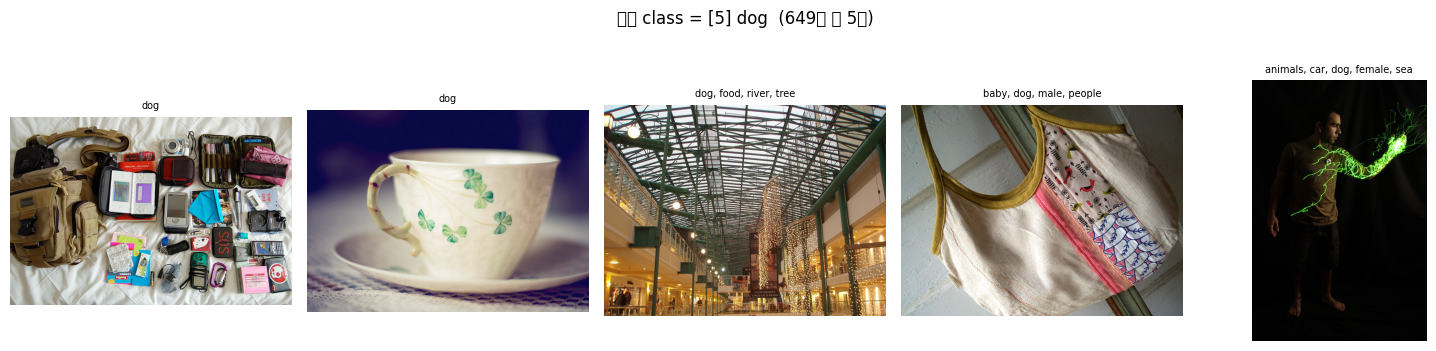

In [3]:
# 빈도 상위 클래스 몇 개에 대해, 각 class를 공통으로 가진 샘플 이미지를 시각화
TOP_K = 5
N_SAMPLES = 5
for class_id in np.argsort(-freq)[:TOP_K]:
    show_class(int(class_id), n_samples=N_SAMPLES, seed=0)